In [ ]:
import re, string; pattern = re.compile('[^a-zA-Z0-9_ ]+')
strip_punct = lambda s: pattern.sub('', s)
text_to_tokens = lambda text: strip_punct(text.lower()).strip().split()
import random
import os 
from pathlib import Path
from collections import Counter
from glob import glob
from tqdm import tqdm
import itertools
import logging
import math
import json
import shutil
import pandas as pd
import pickle
from time import time
from sklearn.manifold import TSNE
import numpy as np
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.decomposition import NMF, LatentDirichletAllocation, MiniBatchNMF
import matplotlib.pyplot as plt
# from util import dict_to_filename, list_dataset_files, read_docs
from sklearn.metrics import pairwise_distances
from sklearn.cluster import KMeans, DBSCAN
import seaborn as sns
from topic_utils import *
import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy.stats import pearsonr, spearmanr
import json
import urllib.request
import urllib.parse
from matplotlib.lines import Line2D

In [2]:
path_data = Path('./data')
path_analyses = path_data / 'corpus_analysis'

In [ ]:
# a few utilities

strip_punct = lambda s: pattern.sub('', s)
text_to_tokens = lambda text: strip_punct(text.lower()).strip().split()
def read_docs(docfiles, max_size=None): 
    """ loads files specified in docfiles into a list of strings """
    docs = []
    size_so_far = 0
    for fpath in docfiles: 
        with open(fpath) as f: 
            docs.append(' '.join(text_to_tokens(f.read())))
        size_so_far += len(docs[-1])
        if max_size and size_so_far >= max_size:
            break
    return docs 

def to_camel_case(s: str) -> str:
    """Convert string (with spaces, underscores, hyphens) to camelCase."""
    parts = re.split(r'[\s_-]+', s.strip())
    if not parts:
        return ""
    return parts[0].lower() + "".join(word.capitalize() for word in parts[1:])

def safe_filename(name: str) -> str:
    """Replace unsafe filename characters with underscores."""
    return re.sub(r'[^A-Za-z0-9._-]', '_', name)

def dict_to_filename(data: dict) -> str:
    """Embed dict into a safe filename with camelCase keys and string values camelCased."""
    parts = []
    for k, v in data.items():
        key = to_camel_case(str(k))
        if isinstance(v, str):
            value = to_camel_case(v)
        else:
            value = str(v)
        parts.append(f"{key}-{value}")
    filename = "_".join(parts)
    return safe_filename(filename)

def list_dataset_files(dataset, lang="en", corpora_root="/Users/rastislavhronsky/research/corpora"): 
    return [fn for fn in glob(os.path.join(corpora_root, dataset, lang, '**'), recursive=True) if fn.endswith('.txt')]


In [ ]:
CORPUS_PATH = Path('/Users/rastislavhronsky/research/corpora')

# load BLP data, will determine our topic modeling vocab
blp_item = pd.read_csv('blp-items.txt', sep='\t', na_values=['NA'], keep_default_na=False)
blp_stim = pd.read_csv('blp-stimuli.txt', sep='\t', na_values=['NA'], keep_default_na=False)
vocab = blp_item[(blp_item.lexicality=='W') & np.isfinite(blp_item.zscore)].spelling.tolist()
vocab_set = set(vocab)

In [ ]:
def create_analysis(analysis_name, n_topics, random_seed, max_doc_size, datasets, overwrite_if_exists=False): 
    # create a list of document paths that will be included in the corpus
    analysis_path = os.path.join('analyses', analysis_name)
    os.makedirs(analysis_path, exist_ok=True)
    docdict_fpath = os.path.join(analysis_path, 'corpus_docs.pkl')
    if os.path.isfile(docdict_fpath): 
        with open(docdict_fpath, 'rb') as f: 
            files = pickle.load(f)
    else: 
        files = {(ds, lang): list_dataset_files(ds, lang, CORPUS_PATH) for ds, lang, _ in datasets}
        # subsample subtitles, there are too many compared to the other corpora
        random.seed(random_seed)
        for ds, lang, proportion in datasets: 
            if proportion < 1.0: 
                files[(ds, lang)] = random.sample(files[(ds, lang)], k=int(proportion*len(files[(ds, lang)])))
        with open(docdict_fpath, 'wb') as f: 
            pickle.dump(files, f)

    files_flat = list(itertools.chain.from_iterable(files.values()))
    print(f"{len(files_flat)} documents from {len(datasets)} data sources will be included in the corpus")
    print("reading documents...")
    train_docs = read_docs(files_flat, max_size=max_doc_size)
    print(f'found {sum(map(lambda d: len(d.encode()), train_docs))/1000000:.3f} MB of data')

    # topic modeling (sklearn's lda) with a hyperparam sweep
    hp_static = dict(
        random_state = random_seed,
        n_jobs=-1,
        learning_method='online', 
        batch_size=2000,
        learning_decay=0.7, 
        learning_offset=10.0,
        max_iter=20,
    )
    vectorizer = CountVectorizer(input='content', vocabulary=vocab, tokenizer=str.split)
    train_docs_vect = vectorizer.fit_transform(train_docs)
    with open(os.path.join(analysis_path, 'vectorizer.pkl'), 'wb') as f: 
        pickle.dump(vectorizer, f)
    for hp_dyn in [dict(n_components=n) for n in n_topics]:
        fit_topic_model(train_docs_vect, 
                        vectorizer=vectorizer, 
                        model_class=LatentDirichletAllocation, 
                        hp_static=hp_static,
                        hp_dyn=hp_dyn, 
                        prefix=f'lda', 
                        analysis_path=analysis_path,
                        overwrite_if_exists=overwrite_if_exists)
    counts = Counter()
    print('creating a frequency list...')
    for doc in tqdm(train_docs):
        tokens = [tok for tok in doc.split() if tok in vocab_set]
        counts += Counter(tokens)
    with open(os.path.join(analysis_path, 'freq.pkl'), 'wb') as f: 
        pickle.dump(counts, f)

In [7]:
create_analysis(analysis_name='en_combi2', 
                n_topics=[2,3,4,5,6,7,8], 
                random_seed=754, 
                max_doc_size=None, 
                datasets=[
                    ('20news-bydate', 'en', 1.0),
                    ('brown_corpus', 'en', 1.0),
                    ('Wikipedia', 'en', 0.5), 
                    ('booksum', 'en', 1.0), 
                    ('OpenSubtitles', 'en', 0.2), 
                    ('BBC', 'en', 1.0),
                ])

92778 documents from 6 data sources will be included in the corpus
reading documents...
found 1334.020 MB of data
fitting model: lda_nComponents-2...
done in 110.12104511260986s
fitting model: lda_nComponents-3...
done in 137.92538905143738s
fitting model: lda_nComponents-4...
done in 154.32664608955383s
fitting model: lda_nComponents-5...
done in 170.5096950531006s
fitting model: lda_nComponents-6...
done in 179.33470392227173s
fitting model: lda_nComponents-7...
done in 185.31039190292358s
fitting model: lda_nComponents-8...
done in 184.25681519508362s
creating a frequency list...


100%|██████████| 92778/92778 [01:18<00:00, 1187.37it/s]


In [5]:
create_analysis(analysis_name='en_news', 
                n_topics=[7], 
                random_seed=754, 
                max_doc_size=None, 
                datasets=[
                    ('20news-bydate', 'en', 1.0),
                    # ('brown_corpus', 'en', 0),
                    # ('Wikipedia', 'en', 0.5), 
                    # ('booksum', 'en', 0), 
                    # ('OpenSubtitles', 'en', 0.2), 
                    ('BBC', 'en', 1.0),
                ])

23932 documents from 2 data sources will be included in the corpus
reading documents...
found 178.969 MB of data
fitting model: lda_nComponents-7...
done in 43.24004077911377s
creating a frequency list...


100%|██████████| 23932/23932 [00:13<00:00, 1712.86it/s]


In [6]:
create_analysis(analysis_name='en_subtitles', 
                n_topics=[7], 
                random_seed=754, 
                max_doc_size=None, 
                datasets=[
                    # ('20news-bydate', 'en', 1.0),
                    # ('brown_corpus', 'en', 0),
                    # ('Wikipedia', 'en', 0.5), 
                    # ('booksum', 'en', 0), 
                    ('OpenSubtitles', 'en', 0.2), 
                    # ('BBC', 'en', 1.0),
                ])

21264 documents from 1 data sources will be included in the corpus
reading documents...
found 552.790 MB of data


/Users/rastislavhronsky/research/amlap2026-word-frequencies-lda/.venv/lib/python3.12/site-packages/sklearn/feature_extraction/text.py:526: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


fitting model: lda_nComponents-7...
done in 62.492602825164795s
creating a frequency list...


100%|██████████| 21264/21264 [00:23<00:00, 902.96it/s]


### analysis with BLP

In [ ]:
def load_analysis(analysis_name): 
    analysis_path = os.path.join('analyses', analysis_name)
    with open(os.path.join(analysis_path, 'freq.pkl'), 'rb') as f: 
        counts = pickle.load(f)
    with open(os.path.join(analysis_path, 'vectorizer.pkl'), 'rb') as f: 
        vectorizer = pickle.load(f)
    with open(os.path.join(analysis_path, 'corpus_docs.pkl'), 'rb') as f: 
        files = pickle.load(f)
    models = {}
    for model_dir in os.listdir(os.path.join(analysis_path, 'topic_models')):
        models[model_dir] = load(os.path.join(os.path.join(analysis_path, 'topic_models', model_dir)))
    return analysis_path, counts, vectorizer, files, models

In [13]:
def create_dataframe(model_and_vectorizer, counts): 
    subset = blp_item[(blp_item.lexicality=='W') & np.isfinite(blp_item.zscore)].copy()
    subset.set_index('spelling', inplace=True)
    subtlex_stats = blp_stim.set_index('spelling').loc[subset.index, blp_stim.columns[blp_stim.columns.str.startswith('subtlex')]]
    subset = subset.join(subtlex_stats)
    subset['subtlex.frequency'] += 1
    subset.columns = subset.columns.str.replace('.', '_')
    freq_ttl = [counts.get(word, 0)+1 for word in subset.index]
    freq_ttl = np.array(freq_ttl)+1
    model, vectorizer = model_and_vectorizer
    assert (vectorizer.get_feature_names_out() != subset.index.to_numpy()).sum() == 0
    dist = model.components_ / model.components_.sum(axis=1)[:, np.newaxis]
    subset['freq'] = freq_ttl
    subset['proba_mean'] = dist.mean(axis=0)
    for i in range(dist.shape[0]): 
        subset[f'proba_{i}'] = dist[i]
    components = [f'np.log(proba_{i})' for i in range(dist.shape[0])]
    formulas = {
        'lda': 'zscore ~ '+' + '.join(components),
        'base': 'zscore ~ np.log(freq)',
        'lda_mean': 'zscore ~ np.log(proba_mean)',
        'subtlex': 'zscore ~ np.log(subtlex_frequency)',
    }
    return subset, formulas

In [14]:
def plot_zipf(model_and_vectorizer): 
    model, _ = model_and_vectorizer
    dist = model.components_ / model.components_.sum(axis=1)[:, np.newaxis]
    for comp in range(dist.shape[0]):
        plt.plot(sorted(dist[comp], reverse=True))
    plt.yscale('log')
    plt.xscale('log')

# plot_zipf(models['lda_nComponents-6'])

In [15]:
def print_differential_words(model_and_vectorizer, topic_n, top_features=100): 
    model, vectorizer = model_and_vectorizer
    ranks_mean = model.components_.mean(0).argsort()[::-1].argsort()+1
    ranks_diff = []
    ranks = []
    for topic_idx, topic in enumerate(model.components_):
        _ranks = topic.argsort()[::-1].argsort()+1
        _diff = (ranks_mean-_ranks)/ranks_mean
        ranks_diff.append((_diff*100).round(2))
        ranks.append(_ranks)
    risers_and_sinkers = ranks_diff[topic_n].argsort()
    risers = risers_and_sinkers[-top_features:][::-1]
    feature_names = vectorizer.get_feature_names_out()
    riser_words = feature_names[risers]
    riser_diffs = ranks_diff[topic_n][risers].tolist()
    riser_ranks = ranks[topic_n][risers].tolist()

    for word, diff, rank in zip(riser_words, riser_diffs, riser_ranks):
        print(f"word: {word}\trank: {rank}\tdiff: {diff}%\t")

In [16]:
def create_dataframe(model_and_vectorizer, counts): 
    subset = blp_item[(blp_item.lexicality=='W') & np.isfinite(blp_item.zscore)].copy()
    subset.set_index('spelling', inplace=True)
    subtlex_stats = blp_stim.set_index('spelling').loc[subset.index, blp_stim.columns[blp_stim.columns.str.startswith('subtlex')]]
    subset = subset.join(subtlex_stats)
    subset['subtlex.frequency'] += 1
    subset.columns = subset.columns.str.replace('.', '_')
    freq_ttl = [counts.get(word, 0)+1 for word in subset.index]
    freq_ttl = np.array(freq_ttl)+1
    model, vectorizer = model_and_vectorizer
    assert (vectorizer.get_feature_names_out() != subset.index.to_numpy()).sum() == 0
    dist = model.components_ / model.components_.sum(axis=1)[:, np.newaxis]
    subset['freq'] = freq_ttl
    subset['proba_mean'] = dist.mean(axis=0)
    for i in range(dist.shape[0]): 
        subset[f'proba_{i}'] = dist[i]
    # components = [f'np.log(proba_{i})' for i in range(dist.shape[0])]
    components = [f'np.log(proba_{i})' for i in range(dist.shape[0])]
    formulas = {
        'lda': 'zscore ~ '+' + '.join(components),
        'freq': 'zscore ~ np.log(freq)',
        'lda_mean': 'zscore ~ np.log(proba_mean)',
        'subtlex': 'zscore ~ np.log(subtlex_frequency)',
    }
    return subset, formulas, dist

analysis_path, counts, vectorizer, files, models = load_analysis('en_subtitles')
model_and_vectorizer = models['lda_nComponents-4']

df, formulas, dist = create_dataframe(model_and_vectorizer, counts)
model = model_and_vectorizer[0]
results = smf.ols(formulas['lda'], data=df).fit()
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:                 zscore   R-squared:                       0.441
Model:                            OLS   Adj. R-squared:                  0.441
Method:                 Least Squares   F-statistic:                     5629.
Date:                Fri, 08 May 2026   Prob (F-statistic):               0.00
Time:                        17:04:18   Log-Likelihood:                -16677.
No. Observations:               28515   AIC:                         3.336e+04
Df Residuals:                   28510   BIC:                         3.341e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept          -2.1185      0.016   -1

In [77]:
print_differential_words(model_and_vectorizer, 2)

word: species	rank: 79	diff: 77.68%	
word: data	rank: 132	diff: 75.42%	
word: systems	rank: 125	diff: 74.95%	
word: highway	rank: 173	diff: 74.78%	
word: route	rank: 101	diff: 74.3%	
word: surface	rank: 234	diff: 74.23%	
word: cells	rank: 279	diff: 74.21%	
word: stations	rank: 147	diff: 73.7%	
word: types	rank: 267	diff: 73.56%	
word: water	rank: 64	diff: 73.33%	
word: models	rank: 262	diff: 73.13%	
word: plants	rank: 309	diff: 73.06%	
word: function	rank: 264	diff: 72.95%	
word: products	rank: 258	diff: 72.78%	
word: plant	rank: 220	diff: 72.74%	
word: railway	rank: 114	diff: 72.66%	
word: rail	rank: 307	diff: 72.61%	
word: trains	rank: 321	diff: 72.61%	
word: traffic	rank: 291	diff: 72.02%	
word: levels	rank: 249	diff: 71.93%	
word: protein	rank: 449	diff: 71.92%	
word: length	rank: 269	diff: 71.83%	
word: software	rank: 382	diff: 71.83%	
word: type	rank: 128	diff: 71.74%	
word: method	rank: 304	diff: 71.4%	
word: engine	rank: 199	diff: 71.24%	
word: patients	rank: 377	diff: 71.13%	


# topviews

In [111]:
# topviews = pd.concat([pd.read_csv("topviews/topviews-2026_04.csv").iloc[:100], 
#                       pd.read_csv("topviews/topviews-2025.csv").iloc[:100],])
topviews = pd.read_csv("topviews/topviews-2025.csv").iloc[:10]
topviews = topviews[~topviews.duplicated('Page')]
topviews

,Page,Edits,Editors,Views,Mobile %
0,Deaths in 2025,26834,933,49505353,55.68
1,Charlie Kirk,3221,740,43195856,80.78
2,ChatGPT,943,223,42736786,64.97
3,Ed Gein,391,232,32826914,91.60
4,Donald Trump,5366,633,27078812,70.57
5,Zohran Mamdani,3208,816,21745414,79.11
6,Elon Musk,2070,482,21184490,75.89
7,Sinners (2025 film),2479,827,19028820,68.12
8,Ozzy Osbourne,1167,353,18353004,82.80
9,Superman (2025 film),1892,421,17519187,73.88


In [416]:
import time
os.makedirs('topviews/wiki-articles', exist_ok=True)
for title in tqdm(topviews.Page): 
    fname = os.path.join('topviews', 'wiki-articles', title.replace(' ', '_')+'.txt')
    if os.path.isfile(fname): continue
    params = urllib.parse.urlencode({
        "action": "query",
        "titles": title,
        "prop": "extracts",
        "explaintext": True,
        "format": "json",
    })
    
    req = urllib.request.Request(
        f"https://en.wikipedia.org/w/api.php?{params}",
        headers={"User-Agent": "wiki_extract/1.0"}
    )
    
    with urllib.request.urlopen(req) as r:
        data = json.loads(r.read())
    
    page = next(iter(data["query"]["pages"].values()))

    with open(fname, 'w') as f: 
        f.write(page["extract"])
    time.sleep(.5)

 79%|███████▉  | 79/100 [00:21<00:05,  3.74it/s]


HTTPError: HTTP Error 429: Too Many Requests

In [180]:
def get_topviews_freq(vectorizer, topviews_selection, flatten=True):
    fnames = []
    for page in topviews_selection: 
        fname = os.path.join('topviews', 'wiki-articles', page.replace(' ', '_')+'.txt')
        if os.path.isfile(fname): fnames.append(fname)
    docs = read_docs(fnames)
    print(f'found {len(docs)} docs')
    topviews_freq = vectorizer.transform(docs).toarray().astype(float)
    if flatten: 
        topviews_freq = topviews_freq.sum(axis=0).flatten()
    return topviews_freq

def get_topviews_rsquared(topviews_selection, model_and_vectorizer, counts, strategy): 
    model, vectorizer = model_and_vectorizer
    topviews_freq = get_topviews_freq(vectorizer, topviews_selection, False)
    cd = (topviews_freq>0).sum(axis=0) / topviews_freq.shape[0]
    topviews_freq = topviews_freq.sum(axis=0)
    # topviews_freq[cd>.7]=0
    # topviews_freq[cd<.3]=0
    # print(vectorizer.get_feature_names_out()[topviews_freq.argsort()[::-1]][:30])

    df_full, formulas, dist = create_dataframe(model_and_vectorizer, counts)
    df = df_full.copy()
    df['topviews'] = topviews_freq

    if strategy == 'smoothing':
        df.topviews += 1e-3
    else: 
        df = df[df.topviews > 0]
    df.topviews = np.log10(df.topviews)
    # print(len(df))
    if len(df) == 0: 
        return {'lda_topviews': 0}

    result = {'pages': topviews_selection}
    formula = formulas['lda'].replace('zscore', 'topviews')
    result_ols = smf.ols(formula, data=df).fit()
    coef_topviews = result_ols.params[1:]

    result_ols = smf.ols(formulas['lda'], data=df_full).fit()
    # print(f"formula: {result_ols.model.formula}")
    # print(f"r^2: {result_ols.rsquared_adj:.4f}")
    coef_rts = result_ols.params[1:]
    result['lda'] = result_ols.rsquared_adj

    result_ols = smf.ols(formulas['freq'], data=df_full).fit()
    # print(f"formula: {result_ols.model.formula}")
    # print(f"r^2: {result_ols.rsquared_adj:.4f}")
    result['freq'] = result_ols.rsquared_adj

    df_full['log_lda_topviews'] = (np.log(dist) * coef_topviews.to_numpy().reshape((-1, 1))).sum(axis=0)
    result_ols = smf.ols("zscore ~ log_lda_topviews", data=df_full).fit()
    # print(f"formula: {result_ols.model.formula}")
    # print(f"r^2: {result_ols.rsquared_adj:.4f}")
    result['lda_topviews'] = result_ols.rsquared_adj
    return result

# analysis_path, counts, vectorizer, files, models = load_analysis('en_wiki')
# model_and_vectorizer = models['lda_nComponents-4']
# results = []
# for page in topviews.Page:
#     topviews_selection = [page,]
#     print(page)
#     results.append(get_topviews_rsquared(topviews_selection, model_and_vectorizer, counts, strategy='smoothing'))
# plt.scatter(coef_rts, coef_topviews)
# top = sorted(results, key=lambda item: item['lda_topviews'], reverse=True)
# N = 1
# topN = [page for item in top[:N] for page in item['pages'] ]


In [327]:

corpora = ['en_wiki', 'en_subtitles', 'en_news', 'en_combination']
results = []

for corpus in corpora: 
    analysis_path, counts, vectorizer, files, models = load_analysis(corpus)
    for n_comp in [2,3,4,5,6,7,8]:
        model_and_vectorizer = models[f'lda_nComponents-{n_comp}']
        for title in topviews.Page: 
            result = get_topviews_rsquared([title], model_and_vectorizer, counts, 'smoothing')
            result['pages'] = result['pages'][0]
            results.append(dict(n_comp=n_comp, corpus=corpus) | result)
results = pd.DataFrame(results).round(5)
results.to_csv('results_topviews.csv')

found 1 docs
found 1 docs
found 1 docs
found 1 docs
found 1 docs
found 1 docs
found 1 docs
found 1 docs
found 1 docs
found 1 docs
found 1 docs
found 1 docs
found 1 docs
found 1 docs
found 1 docs
found 1 docs
found 1 docs
found 1 docs
found 1 docs
found 1 docs
found 1 docs
found 1 docs
found 1 docs
found 1 docs
found 1 docs
found 1 docs
found 1 docs
found 1 docs
found 1 docs
found 1 docs
found 1 docs
found 1 docs
found 1 docs
found 1 docs
found 1 docs
found 1 docs
found 1 docs
found 1 docs
found 1 docs
found 1 docs
found 1 docs
found 1 docs
found 1 docs
found 1 docs
found 1 docs
found 1 docs
found 1 docs
found 1 docs
found 1 docs
found 1 docs
found 1 docs
found 1 docs
found 1 docs
found 1 docs
found 1 docs
found 1 docs
found 1 docs
found 1 docs
found 1 docs
found 1 docs
found 1 docs
found 1 docs
found 1 docs
found 1 docs
found 1 docs
found 1 docs
found 1 docs
found 1 docs
found 1 docs
found 1 docs
found 1 docs
found 1 docs
found 1 docs
found 1 docs
found 1 docs
found 1 docs
found 1 docs

,n_comp,corpus,pages,lda,freq,lda_topviews
0,2,en_wiki,Deaths in 2025,0.34418,0.32782,-0.00004
1,2,en_wiki,Charlie Kirk,0.34418,0.32782,0.33996
2,2,en_wiki,ChatGPT,0.34418,0.32782,0.33215
3,2,en_wiki,Ed Gein,0.34418,0.32782,0.34420
4,2,en_wiki,Donald Trump,0.34418,0.32782,0.33160
...,...,...,...,...,...,...
275,8,en_combination,Zohran Mamdani,0.41446,0.40178,0.28194
276,8,en_combination,Elon Musk,0.41446,0.40178,0.29190
277,8,en_combination,Sinners (2025 film),0.41446,0.40178,0.31235
278,8,en_combination,Ozzy Osbourne,0.41446,0.40178,0.31194


In [ ]:
results = pd.read_csv('results_topviews.csv')
results['delta'] = results.lda_topviews - results.freq
results['delta_max'] = results.lda - results.freq

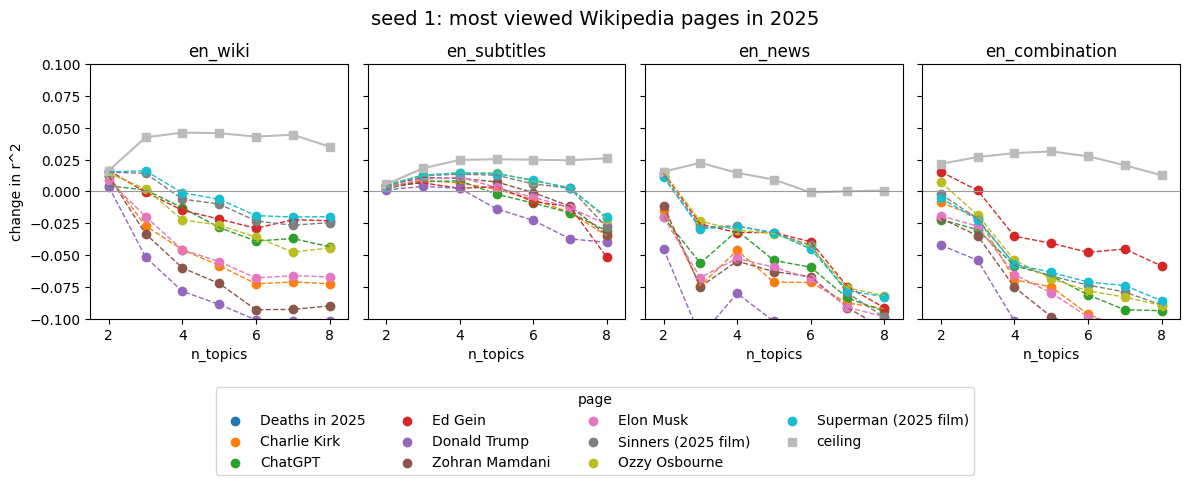

In [ ]:
fig, axes = plt.subplots(nrows=1, ncols=4, figsize=(12,3.5), sharex=True, sharey=True)
axes = axes.flatten()
results['delta'] = results.lda_topviews - results.freq
results['delta_max'] = results.lda - results.freq

for ax, corpus in zip(axes, corpora): 
    colors = plt.cm.tab10.colors
    c = iter(colors)
    for color, page in zip(colors, topviews.Page):
        subset = results[(results.corpus==corpus) & (results.pages==page)]
        ax.plot(subset.n_comp, subset.delta, color=color, linewidth=1, linestyle='--')
        ax.scatter(subset.n_comp, subset.delta, color=color, label=page)
    ax.plot(subset.n_comp, subset.delta_max, color='#bbb')
    ax.scatter(subset.n_comp, subset.delta_max, color='#bbb', label='ceiling', marker='s')
    ax.plot([1.5,8.5], [0,0], color='#999', linewidth=.8)
    ax.set_xlim([1.5,8.5])
    ax.set_ylim((-.10,.10))
    ax.set_title(corpus)
    if corpus==corpora[0]:
        ax.set_ylabel('change in r^2')
    ax.set_xlabel('n_topics')
# fig.legend(title='seed page')
handles, labels = ax.get_legend_handles_labels()
fig.legend(title='page', handles=handles[:len(topviews)+1], labels=labels[:len(topviews)+1], loc='lower center', bbox_to_anchor=(.5,-.3), ncol=4)
fig.tight_layout()
fig.suptitle('seed 1: most viewed Wikipedia pages in 2025', y=1.05, fontsize=14)
fig.savefig('topviews.pdf', format='pdf',  bbox_inches='tight')

# swow

In [305]:
swow = pd.read_csv('SWOW-EN18/responseStats.SWOW-EN.20180827.csv')
swow = swow.set_index('response')
swow = swow.fillna(0)
swow.index = swow.index.str.lower()
swow_set = set(swow.index.tolist())
swow = swow[swow.columns[swow.columns.str.contains('Freq')]]
swow.columns = swow.columns.str.replace('.', '_')
swow.columns = swow.columns.str.lower()
swow = swow.groupby(level=0).sum()
shared_index = [word for word in vectorizer.get_feature_names_out() if word in swow_set]
swow = swow.loc[shared_index]

swow.loc[~np.isfinite(swow['freq_r1']), 'freq_r1'] = 0.0
swow.loc[~np.isfinite(swow['freq_r123']), 'freq_r123'] = 0.0
swow['freq_r1'] += 1
swow['freq_r123'] += 1
swow['freq_r123'] = swow['freq_r123'].astype(float)
swow['log_freq_1'] = np.log10(swow['freq_r1'])
swow['log_freq_123'] = np.log10(swow['freq_r123'])
# swow = swow.sort_values('response')
swow

,freq_r1,freq_r123,log_freq_1,log_freq_123
response,,,,
aback,4.0,8.0,0.602060,0.903090
abaft,1.0,3.0,0.000000,0.477121
abase,4.0,9.0,0.602060,0.954243
abashed,2.0,7.0,0.301030,0.845098
abate,3.0,11.0,0.477121,1.041393
...,...,...,...,...
zonked,1.0,2.0,0.000000,0.301030
zoo,79.0,354.0,1.897627,2.549003
zoom,34.0,111.0,1.531479,2.045323


In [ ]:
sizes = (2 ** np.arange(4,14)).tolist() + [len(swow)]
corpora = ['en_wiki', 'en_subtitles', 'en_news', 'en_combination']
results = []
nsim = 30

for corpus in corpora: 
    analysis_path, counts, vectorizer, files, models = load_analysis(corpus)
    for n_comp in [2,3,4,5,6,7,8]:
        model_and_vectorizer = models[f'lda_nComponents-{n_comp}']
        df_full, formulas, dist = create_dataframe(model_and_vectorizer, counts)
        df = df_full.copy().loc[shared_index]
        df = df.join(swow)
        assert (df.index != swow.index).sum()==0
        
        for sim_i in range(nsim):
            for size in sizes: 
                result = {'sim': sim_i}
                formula = formulas['lda'].replace('zscore', 'log_freq_1')
                result_ols = smf.ols(formula, data=df.sample(size)).fit()
                coef = result_ols.params[1:]
                result_ols = smf.ols(formulas['lda'], data=df_full).fit()
                result['lda'] = result_ols.rsquared_adj
                result_ols = smf.ols(formulas['freq'], data=df_full).fit()
                result['freq'] = result_ols.rsquared_adj
                df_full['lda_log_freq_1'] = (np.log(dist) * coef.to_numpy().reshape((-1, 1))).sum(axis=0)
                result_ols = smf.ols("zscore ~ lda_log_freq_1", data=df_full).fit()
                result['lda_log_freq_1'] = result_ols.rsquared_adj
                result = result | dict(corpus=corpus, n_comp=n_comp, size=size)
                results.append(result)

results = pd.DataFrame(results).round(5)
results['delta'] = results.lda_log_freq_1 - results.freq
results['delta_max'] = results.lda - results.freq
results.to_csv('results_swow.csv')

In [ ]:
analysis_path, counts, vectorizer, files, models = load_analysis('en_subtitles')
model_and_vectorizer = models['lda_nComponents-4']
model, vectorizer = model_and_vectorizer
df_full, formulas, dist = create_dataframe(model_and_vectorizer, counts)
df = df_full.copy().loc[shared_index]
df = df.join(swow)
assert (df.index != swow.index).sum()==0
shared_set = set(shared_index)
mask = [word in shared_set for word in vectorizer.get_feature_names_out()]

In [ ]:
result = {}
formula = formulas['lda'].replace('zscore', 'log_freq_1')
result_ols = smf.ols(formula, data=df.sample(10000)).fit()
coef = result_ols.params[1:]

result_ols = smf.ols(formulas['lda'], data=df_full).fit()
print(f"formula: {result_ols.model.formula}")
print(f"r^2: {result_ols.rsquared_adj:.4f}")
result['lda'] = result_ols.rsquared_adj

result_ols = smf.ols(formulas['freq'], data=df_full).fit()
print(f"formula: {result_ols.model.formula}")
print(f"r^2: {result_ols.rsquared_adj:.4f}")
result['freq'] = result_ols.rsquared_adj

df_full['lda_log_freq_1'] = (np.log(dist) * coef.to_numpy().reshape((-1, 1))).sum(axis=0)
result_ols = smf.ols("zscore ~ lda_log_freq_1", data=df_full).fit()
print(f"formula: {result_ols.model.formula}")
print(f"r^2: {result_ols.rsquared_adj:.4f}")
# result['lda_topviews'] = result_ols.rsquared_adj
# return result

formula: zscore ~ np.log(proba_0) + np.log(proba_1) + np.log(proba_2) + np.log(proba_3)
r^2: 0.4412
formula: zscore ~ np.log(freq)
r^2: 0.4164
formula: zscore ~ lda_log_freq_1
r^2: 0.4352


In [361]:
results_swow = pd.read_csv('results_swow.csv')
agg = results.groupby(['corpus', 'n_comp', 'size'])[['lda', 'lda_log_freq_1', 'freq']].agg(['mean', 'std']).reset_index()
results_topviews = pd.read_csv('results_topviews.csv')

In [450]:
subset_topviews.sort_values('lda_topviews', ascending=False).iloc[:8]

,Unnamed: 0,n_comp,corpus,pages,lda,freq,lda_topviews
167,167,4,en_news,Sinners (2025 film),0.39827,0.3837,0.35666
169,169,4,en_news,Superman (2025 film),0.39827,0.3837,0.35609
168,168,4,en_news,Ozzy Osbourne,0.39827,0.3837,0.35329
162,162,4,en_news,ChatGPT,0.39827,0.3837,0.35284
163,163,4,en_news,Ed Gein,0.39827,0.3837,0.35132
161,161,4,en_news,Charlie Kirk,0.39827,0.3837,0.33735
166,166,4,en_news,Elon Musk,0.39827,0.3837,0.33099
165,165,4,en_news,Zohran Mamdani,0.39827,0.3837,0.32879


<>:46: SyntaxWarning: invalid escape sequence '\%'
<>:46: SyntaxWarning: invalid escape sequence '\%'
/var/folders/n_/nb0nr2sd6_925f9251v_rm_w0000gn/T/ipykernel_99012/1154900746.py:46: SyntaxWarning: invalid escape sequence '\%'
  ax.set_ylabel(f"{corpus}\n$\%R^2$")


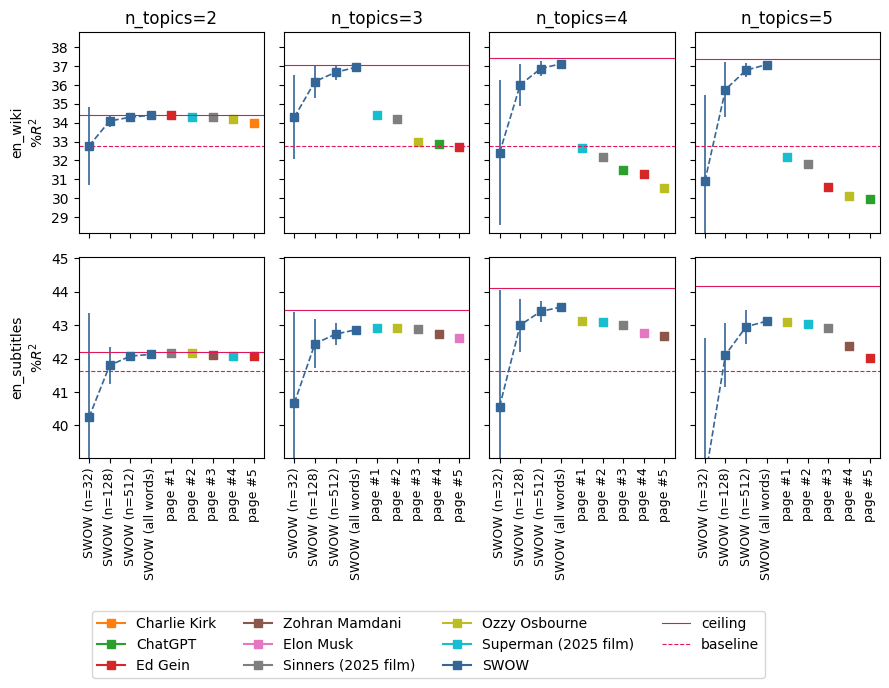

In [563]:
topics = [2,3,4,5]
corpora = ['en_wiki', 'en_subtitles']
fig, axes = plt.subplots(nrows=len(corpora), ncols=len(topics), figsize=(9, 6), sharex=True,)
axes = iter(axes.flatten())

colors = dict(zip(topviews.Page, plt.cm.tab10.colors))
color_swow = "#346698"
pages_included = set()

for corpus in corpora:
    for n_comp in topics:
        ax = next(axes)
        subset_swow = results_swow[(results_swow.n_comp==n_comp)&(results_swow.corpus==corpus)]
        swow_points = subset_swow.groupby(['size'])['lda_log_freq_1'].agg(['mean', 'std'])
        sizes = [32, 128, 512, len(swow)]
        # ax.plot(np.arange(len(sizes)), swow_points.loc[sizes]['mean'], c='#999', linestyle='--', linewidth=.8)
        ax.errorbar(np.arange(len(sizes)), swow_points.loc[sizes]['mean'], yerr=swow_points.loc[sizes]['std'], linestyle='--', linewidth=1.2, marker='s', color=color_swow)

        subset_topviews = results_topviews[(results_topviews.n_comp==n_comp)&(results_topviews.corpus==corpus)]
        n=5
        topn = subset_topviews.sort_values('lda_topviews', ascending=False).iloc[:n]
        pages_included.update(topn.pages.tolist())
        # ax.scatter(np.arange(n)+len(sizes), topn.lda_topviews, marker='s', color="#35cce3")
        x_offset = len(sizes)
        for i, row in topn.iterrows(): 
            ax.scatter(x_offset, row.lda_topviews, marker='s', label=row.pages, color=colors[row.pages])
            x_offset += 1

        ax.set_xticks(ticks=np.arange(len(sizes)+n), labels=[f'SWOW (n={s})' for s in sizes[:-1]] + ["SWOW (all words)"] + [f"page #{i+1}" for i in range(n)], rotation=90, fontsize=9)
        xlim = [-.5,n+len(sizes)-.5]
        ceiling_val = subset_swow.lda.iloc[0]
        baseline_val = subset_swow.freq.iloc[0]
        ax.plot(xlim, [ceiling_val]*2, label='ceiling', linewidth=.8, c="#df185a")
        ax.plot(xlim, [baseline_val]*2, label='baseline', linewidth=.8, c="#df185a", linestyle='--')
        ax.set_xlim(xlim)
        ceiling_corpus = results_topviews[results_topviews.corpus==corpus].lda.max()
        baseline_corpus = results_topviews[results_topviews.corpus==corpus].freq.max()
        ylim = (min(baseline_corpus-1.0*(ceiling_corpus-baseline_corpus), topn.lda_topviews.min()-.01), 
                ceiling_corpus+.3*(ceiling_corpus-baseline_corpus))
        yticks = np.arange(np.ceil(ylim[0]*100), np.ceil(ylim[1]*100), step=1)/100
        ax.set_yticks(yticks, labels=[f'{yt*100:.0f}' for yt in yticks])
        ax.set_ylim(ylim)
        if n_comp>2: 
            ax.set_yticklabels([])
        if n_comp==2:
            ax.set_ylabel(f"{corpus}\n$\%R^2$")
        if corpus == corpora[0]: 
            ax.set_title(f"n_topics={n_comp}")

fig.tight_layout()
handles, labels = ax.get_legend_handles_labels()
handles = handles[-2:]
labels = labels[-2:]
for page, clr in colors.items(): 
    if page not in pages_included: continue
    handles.append(Line2D([0], [0], marker='s', color=clr))
    labels.append(page)
handles.append(Line2D([0],[0], marker='s', color=color_swow))
labels.append('SWOW')
fig.legend(handles[2:]+handles[:2], labels[2:]+labels[:2], loc='lower left', ncol=4, bbox_to_anchor=(0.1,-.15))
fig.savefig('results.pdf', format='pdf',  bbox_inches='tight')

In [559]:
yticks

array([0.4   , 0.4001, 0.4002, 0.4003, 0.4004, 0.4005, 0.4006, 0.4007,
       0.4008, 0.4009, 0.401 , 0.4011, 0.4012, 0.4013, 0.4014, 0.4015,
       0.4016, 0.4017, 0.4018, 0.4019, 0.402 , 0.4021, 0.4022, 0.4023,
       0.4024, 0.4025, 0.4026, 0.4027, 0.4028, 0.4029, 0.403 , 0.4031,
       0.4032, 0.4033, 0.4034, 0.4035, 0.4036, 0.4037, 0.4038, 0.4039,
       0.404 , 0.4041, 0.4042, 0.4043, 0.4044, 0.4045, 0.4046, 0.4047,
       0.4048, 0.4049, 0.405 , 0.4051, 0.4052, 0.4053, 0.4054, 0.4055,
       0.4056, 0.4057, 0.4058, 0.4059, 0.406 , 0.4061, 0.4062, 0.4063,
       0.4064, 0.4065, 0.4066, 0.4067, 0.4068, 0.4069, 0.407 , 0.4071,
       0.4072, 0.4073, 0.4074, 0.4075, 0.4076, 0.4077, 0.4078, 0.4079,
       0.408 , 0.4081, 0.4082, 0.4083, 0.4084, 0.4085, 0.4086, 0.4087,
       0.4088, 0.4089, 0.409 , 0.4091, 0.4092, 0.4093, 0.4094, 0.4095,
       0.4096, 0.4097, 0.4098, 0.4099, 0.41  , 0.4101, 0.4102, 0.4103,
       0.4104, 0.4105, 0.4106, 0.4107, 0.4108, 0.4109, 0.411 , 0.4111,
      

# zipf

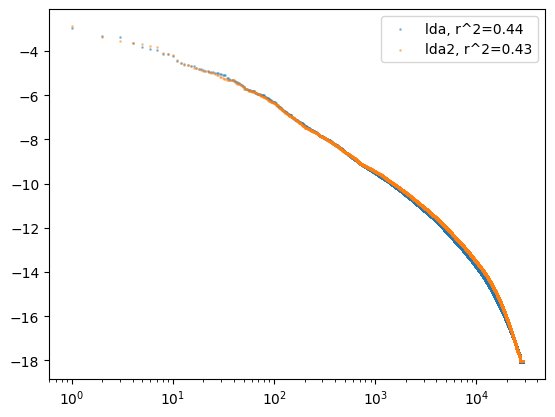

In [239]:
def plot_zipf2(results, label, dist, ax, weights = None): 
    intercept = results.params.iloc[0]
    # weights = np.array([0.0067,-0.0162,-0.0560,-0.0847]).reshape(-1,1)
    weights = np.array(results.params[1:] if weights is None else weights).reshape(-1,1)
    weights = weights / weights.sum()
    weighted = (np.log(dist) * weights).sum(axis=0)
    weighted = np.exp(weighted)
    weighted /= weighted.sum()
    weighted = np.log(weighted)
    pearson = pearsonr(weighted, df.zscore)
    plt.scatter(1+np.arange(len(weighted)), np.sort(weighted)[::-1],
                label=f"{label}, r^2={pearson[0]**2:.2f}", s=1, alpha=.4)

ax = plt.subplot()
# results = smf.ols(formulas['freq'], data=df).fit()
# plot_zipf2(results, 'raw_freq', dist, ax)

results = smf.ols(formulas['lda'], data=df).fit()
plot_zipf2(results, 'lda', dist, ax)
plot_zipf2(results, 'lda2', dist, ax, weights = [0.01,0.02,0.09,0.05])

# results = smf.ols(formulas['subtlex'], data=df).fit()
# plot_zipf2(results, 'subtlex', dist, ax)

# results = smf.ols(formulas['lda_mean'], data=df).fit()
# plot_zipf2(results, 'lda_mean', dist, ax)

ax.set_xscale('log')
plt.legend()

# topic spread

In [65]:
model = model_and_vectorizer[0]
dist = model.components_ / model.components_.sum(axis=1)[:, np.newaxis]
df['spread'] = dist.T.std(axis=1)/dist.T.mean(axis=1)
results = smf.ols('zscore ~ np.log(freq) * spread', data=df).fit()
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:                 zscore   R-squared:                       0.426
Model:                            OLS   Adj. R-squared:                  0.426
Method:                 Least Squares   F-statistic:                     7055.
Date:                Thu, 07 May 2026   Prob (F-statistic):               0.00
Time:                        17:24:08   Log-Likelihood:                -17060.
No. Observations:               28515   AIC:                         3.413e+04
Df Residuals:                   28511   BIC:                         3.416e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
Intercept               0.6414    

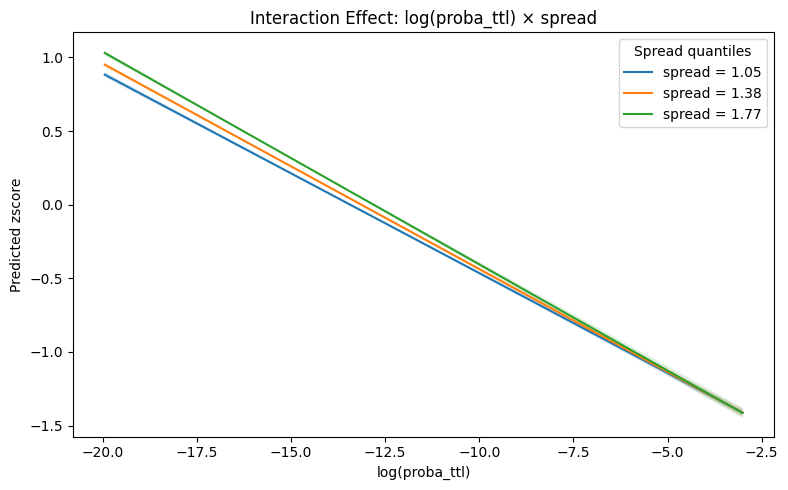

In [66]:
# Pick representative values of spread (e.g. quartiles)
spread_values = df['spread'].quantile([0.25, 0.50, 0.75]).values
log_proba_range = np.linspace(
    np.log(df['proba_ttl']).min(),
    np.log(df['proba_ttl']).max(),
    100
)

fig, ax = plt.subplots(figsize=(8, 5))

for s in spread_values:
    pred_df = pd.DataFrame({
        'proba_ttl': np.exp(log_proba_range),  # back to original scale
        'spread': s
    })
    preds = results.get_prediction(pred_df).summary_frame(alpha=0.05)
    
    ax.plot(log_proba_range, preds['mean'], label=f'spread = {s:.2f}')
    ax.fill_between(log_proba_range, preds['mean_ci_lower'], preds['mean_ci_upper'], alpha=0.15)

ax.set_xlabel('log(proba_ttl)')
ax.set_ylabel('Predicted zscore')
ax.set_title('Interaction Effect: log(proba_ttl) × spread')
ax.legend(title='Spread quantiles')
plt.tight_layout()
plt.show()